In [4]:
import matplotlib.pyplot as pl
import numpy as np
import pandas as pd
import xarray as xr
import math
import pickle

from fair import FAIR
from fair.interface import fill, initialise
from fair.io import read_properties
from pygments.lexers.textfmts import TodotxtLexer

import statsmodels.api as sm
import pmdarima as pm


In [2]:
with open("/glade/work/stevenxu/FAIR_models/origional_model.pkl", "rb") as f_in:
    f1 = pickle.load(f_in)

with open("/glade/work/stevenxu/FAIR_models/top12_model.pkl", "rb") as f_in:
    f2 = pickle.load(f_in)

with open("/glade/work/stevenxu/FAIR_models/top20_model.pkl", "rb") as f_in:
    f3 = pickle.load(f_in)

In [3]:
fancy_titles = {
    'ssp119': 'ssp119',
    'ssp126': 'ssp126',
    'ssp245': 'ssp245',
    'ssp370': 'ssp370',
    'ssp434': 'ssp434',
    'ssp460': 'ssp460',
    'ssp534-over': 'ssp534-over',
    'ssp585': 'ssp585'
}

colors = {
    'ssp119': '#0000FF',    # Dark blue for lowest emissions
    'ssp126': '#4169E1',    # Royal blue
    'ssp245': '#00BFFF',    # Deep sky blue
    'ssp370': '#FFD700',    # Gold
    'ssp434': '#FFA500',    # Orange
    'ssp460': '#FF4500',    # Orange red
    'ssp534-over': '#DC143C',    # Crimson
    'ssp585': '#8B0000'     # Dark red for highest emissions
}

weights_51yr = np.ones(52)
weights_51yr[0] = 0.5
weights_51yr[-1] = 0.5

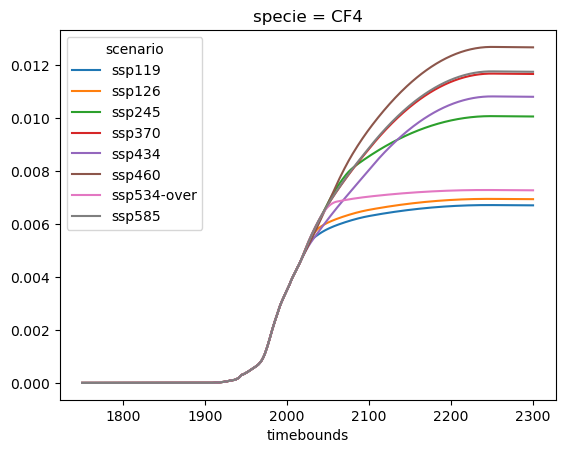

In [ ]:
scenario = 'ssp585'
specie = 'CF4'
da = f1.forcing.sel(specie=specie).mean(dim="config")
da.plot.line(x="timebounds")

## Finding the year when data diverges by scenarios
2017

In [ ]:
for specie in f1.species:
    config = f1.configs[0]  # taking first config
    da = f1.forcing.sel(config=config, specie=specie)
    spread = da.max(dim="scenario") - da.min(dim="scenario")

    # Find the first year when spread is strictly greater than zero
    different_mask = spread > 0
    if different_mask.any():
        first_idx = int(np.argmax(different_mask.values))  # index of first True
        year_start_diff = int(spread["timebounds"].values[first_idx])
        print(specie, ': ' , year_start_diff)
    else:
        print(specie, ': ' , "never diverges")

List of species that forcing is not existing

In [ ]:
no_forcing_species = []
for specie in f1.species:
    da = f1.forcing.sel(scenario = f1.scenarios[0], specie=specie).mean(dim="config")
    if da.sum() == 0:
        no_forcing_species.append(specie)

no_forcing_species

['CO2 FFI',
 'CO2 AFOLU',
 'Sulfur',
 'BC',
 'OC',
 'NH3',
 'NOx',
 'VOC',
 'CO',
 'Equivalent effective stratospheric chlorine']

# Arima Fitting for each specie

In [129]:
org_specie = f1.species
species_with_forcing = [s for s in org_specie if s not in no_forcing_species]
arima_list = {}
count = 0

for specie in species_with_forcing:
    count += 1
    print("Fitting ARIMA for ", specie, " ", count, "/", len(species_with_forcing))
    da = f1.forcing.sel(scenario = f1.scenarios[5], specie=specie, timebounds = slice(None, 2017)).mean(dim="config")
    model = pm.auto_arima(da.values, start_p=1, start_q=1,
                                max_p=3, max_q=3, m=12,
                                start_P=0, seasonal=True,
                                d=1, D=1, trace=True,
                                error_action='ignore',  # don't want to know if an order does not work
                                suppress_warnings=True,  # don't want convergence warnings
                                stepwise=True)  # set to stepwise
    arima_list[specie] = model

arima_list


Fitting ARIMA for  CO2   1 / 51
Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=-2732.852, Time=1.38 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=-2308.015, Time=0.09 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=-2619.886, Time=0.41 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=-2533.984, Time=0.43 sec
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=-2768.979, Time=0.16 sec
 ARIMA(1,1,1)(1,1,0)[12]             : AIC=-2618.804, Time=0.86 sec
 ARIMA(1,1,1)(1,1,1)[12]             : AIC=-2716.819, Time=0.65 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=-2533.346, Time=0.31 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=-2770.680, Time=0.22 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=-2734.281, Time=0.35 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=-2718.583, Time=0.66 sec
 ARIMA(2,1,0)(0,1,0)[12]             : AIC=-2768.914, Time=0.17 sec
 ARIMA(2,1,1)(0,1,0)[12]             : AIC=-2302.051, Time=0.40 sec
 ARIMA(1,1,0)(0,1,0)[12] intercept   : AI

/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:1905: RuntimeWarning: divide by zero encountered in reciprocal
  return np.roots(self.polynomial_reduced_ma)**-1


 ARIMA(1,1,1)(0,1,2)[12]             : AIC=-4295.436, Time=0.80 sec
 ARIMA(1,1,1)(1,1,0)[12]             : AIC=-4146.303, Time=0.73 sec
 ARIMA(1,1,1)(1,1,2)[12]             : AIC=-4149.761, Time=7.07 sec


/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:1905: RuntimeWarning: divide by zero encountered in reciprocal
  return np.roots(self.polynomial_reduced_ma)**-1


 ARIMA(1,1,0)(0,1,1)[12]             : AIC=-4278.281, Time=0.36 sec
 ARIMA(2,1,1)(0,1,1)[12]             : AIC=-4307.562, Time=1.57 sec
 ARIMA(2,1,1)(0,1,0)[12]             : AIC=-4309.044, Time=1.71 sec
 ARIMA(2,1,1)(1,1,0)[12]             : AIC=-4145.095, Time=2.18 sec
 ARIMA(2,1,1)(1,1,1)[12]             : AIC=-3820.841, Time=5.20 sec
 ARIMA(2,1,0)(0,1,0)[12]             : AIC=-4308.969, Time=0.85 sec
 ARIMA(3,1,1)(0,1,0)[12]             : AIC=-4301.997, Time=0.27 sec
 ARIMA(2,1,2)(0,1,0)[12]             : AIC=-4296.305, Time=0.47 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=-4280.281, Time=0.15 sec
 ARIMA(1,1,2)(0,1,0)[12]             : AIC=-4303.878, Time=0.62 sec
 ARIMA(3,1,0)(0,1,0)[12]             : AIC=-4291.916, Time=0.30 sec
 ARIMA(3,1,2)(0,1,0)[12]             : AIC=-4305.932, Time=0.47 sec
 ARIMA(2,1,1)(0,1,0)[12] intercept   : AIC=-4306.718, Time=0.90 sec

Best model:  ARIMA(2,1,1)(0,1,0)[12]          
Total fit time: 28.325 seconds
Fitting ARIMA for  CFC-11   4 / 51
Pe

...

/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:1905: RuntimeWarning: divide by zero encountered in reciprocal
  return np.roots(self.polynomial_reduced_ma)**-1


 ARIMA(2,1,1)(0,1,0)[12]             : AIC=-5115.814, Time=0.59 sec
 ARIMA(1,1,0)(0,1,0)[12] intercept   : AIC=-5391.332, Time=0.52 sec

Best model:  ARIMA(1,1,0)(0,1,0)[12]          
Total fit time: 4.652 seconds
Fitting ARIMA for  HFC-4310mee   43 / 51
Performing stepwise search to minimize aic


/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:1905: RuntimeWarning: divide by zero encountered in reciprocal
  return np.roots(self.polynomial_reduced_ma)**-1


 ARIMA(1,1,1)(0,1,1)[12]             : AIC=-5162.051, Time=0.43 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=-6179.508, Time=0.32 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=-4669.915, Time=0.48 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=-6175.508, Time=1.00 sec
 ARIMA(0,1,0)(1,1,0)[12]             : AIC=-6180.043, Time=0.42 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=-6175.508, Time=1.50 sec
 ARIMA(0,1,0)(1,1,1)[12]             : AIC=-6177.906, Time=0.58 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=-6177.508, Time=0.77 sec
 ARIMA(0,1,0)(2,1,1)[12]             : AIC=-5819.809, Time=0.74 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=-6178.043, Time=0.56 sec
 ARIMA(1,1,1)(1,1,0)[12]             : AIC=-5172.300, Time=1.19 sec
 ARIMA(0,1,0)(1,1,0)[12] intercept   : AIC=-5367.585, Time=2.17 sec

Best model:  ARIMA(0,1,0)(1,1,0)[12]          
Total fit time: 10.155 seconds
Fitting ARIMA for  Solar   44 / 51
Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[12]   

{'CO2': ARIMA(order=(1, 1, 0), scoring_args={}, seasonal_order=(0, 1, 0, 12),
       suppress_warnings=True),
 'CH4': ARIMA(order=(2, 1, 0), scoring_args={}, seasonal_order=(0, 1, 0, 12),
       suppress_warnings=True, with_intercept=False),
 'N2O': ARIMA(order=(2, 1, 1), scoring_args={}, seasonal_order=(0, 1, 0, 12),
       suppress_warnings=True, with_intercept=False),
 'CFC-11': ARIMA(order=(2, 1, 3), scoring_args={}, seasonal_order=(0, 1, 0, 12),
       suppress_warnings=True, with_intercept=False),
 'CFC-12': ARIMA(order=(1, 1, 2), scoring_args={}, seasonal_order=(0, 1, 0, 12),
       suppress_warnings=True, with_intercept=False),
 'CFC-113': ARIMA(order=(2, 1, 2), scoring_args={}, seasonal_order=(1, 1, 1, 12),
       suppress_warnings=True, with_intercept=False),
 'CFC-114': ARIMA(order=(1, 1, 0), scoring_args={}, seasonal_order=(0, 1, 2, 12),
       suppress_warnings=True, with_intercept=False),
 'CFC-115': ARIMA(order=(2, 1, 2), scoring_args={}, seasonal_order=(1, 1, 1, 12),
  

Saving list of model

In [130]:
save_path = "/glade/work/stevenxu/FAIR_models/arima_list.pkl"
with open(save_path, "wb") as f:
    pickle.dump(arima_list, f)